<a href="https://colab.research.google.com/github/David-Mares-Silva/CodigoIAM_Cerebro/blob/main/Clustering_de_Establecimientos_de_salud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering Establecimientos de Salud con Python
En este Notebook se presentan los datos de localización de establecimientos de salud con coordenadas y se busca definir la regionalización idonea (qué unidades deben agruparse para poder realizar acciones de salud pública optimizaas sobre el territorio y sobre cada región.

Se utiliza como datos de muestra las unidades de salud del estado de Hidalgo México.

## Prerequisitos
- Habilitades de graficos en 2-D con Matplotlib.
- Manejo básico de Pandas para manipulación de dataframes.
- Conceptos detras de algoritmos de clustering.

## Tareas principales

[**Tarea 1**](#Tarea1): Analisis Exploratorio de Datos

[**Tarea 2**](#Tarea2): Visualización de Datos Geográficso

[**Tarea 3**](#Tarea3): Clustering Strength / Performance Metric

[**Tarea 4**](#Tarea4): Algoritmo K-Means

[**Tarea 5**](#Tarea5): DBSCAN

[**Tarea 6**](#Tarea6): HDBSCAN

[**Tarea 7**](#Tarea7): Tratamiento de Outliers


In [ ]:
import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'svg'
import matplotlib.pyplot as plt
plt.style.use('ggplot')

import pandas as pd
import numpy as np

from tqdm import tqdm

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs
from sklearn.neighbors import KNeighborsClassifier

from ipywidgets import interactive

from collections import defaultdict

import hdbscan
import folium
import re


cols = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4',
        '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff',
        '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1',
        '#000075', '#808080']*10

#Tarea1: Analisis Exploratorio de Datos

In [22]:

# Reading the Data
df = pd.read_csv('HGO.csv')
df.tail()


,NOMBRE DE LA UNIDAD,NOMBRE TIPO ESTABLECIMIENTO,LATITUD,LONGITUD
1244,CENTRO COMUNITARIO DE SALUD MENTAL Y ADICCIONE...,DE CONSULTA EXTERNA,21.168241,-98.606126
1245,CENTRO COMUNITARIO DE SALUD MENTAL Y ADICCIONE...,DE CONSULTA EXTERNA,20.036810,-99.330300
1246,CENTRO COMUNITARIO DE SALUD MENTAL Y ADICCIONE...,DE CONSULTA EXTERNA,20.117362,-98.782300
1247,SERVICIO AMIGABLE ITINERANTE EDUSEX,DE CONSULTA EXTERNA,20.066549,-98.770564
1248,CENTRO DE SALUD SANTA TERESA,DE CONSULTA EXTERNA,20.899630,-98.386060


In [23]:
df.shape

(1249, 4)

In [24]:
# Revisar por valores duplicados
df.duplicated(subset = ['LONGITUD', 'LATITUD']).values.any()


np.True_

In [25]:

# Revisión de valores NAN
df.isna().values.any()


np.True_

In [26]:
# Dropping NaNs and duplicated values

print(f'Tamaño del df antes de remover NaNs y duplicados\t:\tdf.shape = {df.shape}')
df.dropna(inplace = True)
print(f'Después de remover NaNs\t\t\t\t\t:\tdf.shape = {df.shape}')
df.drop_duplicates(subset = ['LONGITUD','LATITUD'],keep = 'first',inplace = True)
print(f'Dsespues de NaNs and duplicados\t\t\t\t:\tdf.shape = {df.shape}')

Tamaño del df antes de remover NaNs y duplicados	:	df.shape = (1249, 4)
Después de remover NaNs					:	df.shape = (1247, 4)
Dsespues de NaNs and duplicados				:	df.shape = (1188, 4)


In [27]:

# Feature Array
X = np.array(df[['LONGITUD','LATITUD']],dtype = 'float64') #float64 so that we dont lose on information.
X


array([[-98.7207722,  20.1077298],
       [-98.2056   ,  20.1583   ],
       [-98.7295625,  20.1186192],
       ...,
       [-98.7823   ,  20.117362 ],
       [-98.770564 ,  20.066549 ],
       [-98.38606  ,  20.89963  ]])

Text(0, 0.5, 'LATITUD')

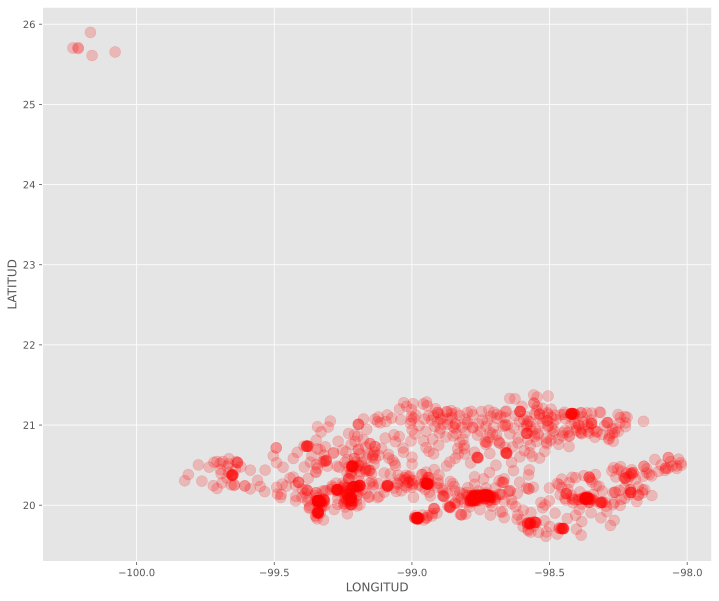

In [20]:
# Visualising taxi ranks in a 2-D plot
plt.figure(figsize=(12,10))
plt.scatter(X[:,0],X[:,1],alpha = 0.2, s=120,color = 'r')
plt.xlabel('LONGITUD')
plt.ylabel('LATITUD')


Se puede observar que hay coordenadas que salen del rango de coordenadas UMT que abarca al estado de Hidalgo.